In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
pip uninstall seaborn -y
pip cache purge
pip install seaborn

SyntaxError: invalid syntax (922043855.py, line 1)

In [5]:
!pip uninstall seaborn -y

Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2


In [6]:
!pip cache purge
!pip install seaborn

Files removed: 6
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.9 kB 751.6 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import seaborn
print(seaborn.__version__)

0.13.2


In [8]:
df=pd.read_csv(r'C:/Users/Lenovo/Desktop/Resume Screening using python/Resume.csv')

In [9]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [10]:
df.shape

(2484, 4)

Exploring Categories

In [11]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

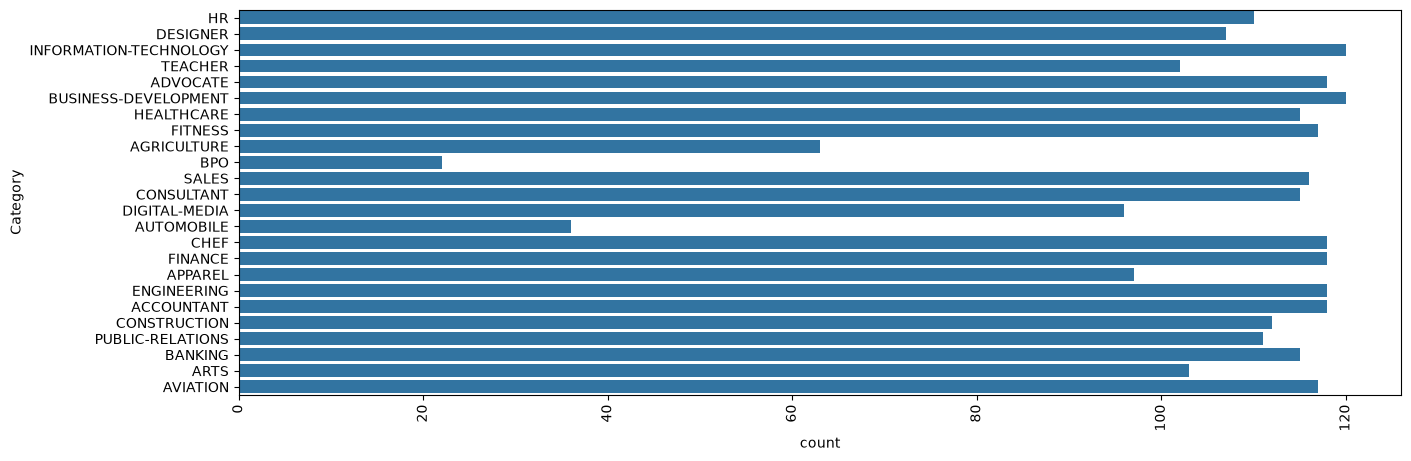

In [12]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [13]:
df['Category'].unique()

<ArrowStringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str

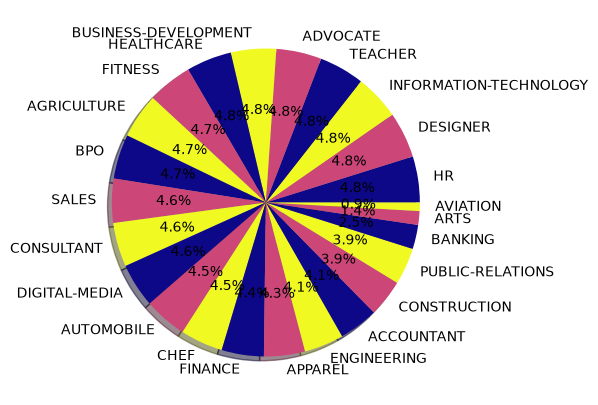

In [14]:
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(15,5))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True,colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

Exploring Resume

In [15]:
df['Category'][0]

'HR'

In [16]:
df['Resume_str'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

Cleaning Data:
1) URLs,
2) hasthags,
3) mentions,
4) special items,
5) punctuations:

In [17]:
import re
def cleanResume(txt):
    cleanTxt=re.sub(r'http\S+\s',' ',txt)
    cleanTxt=re.sub(r'@\S+',' ',cleanTxt)
    cleanTxt=re.sub(r'#\S+\s',' ',cleanTxt)
    cleanTxt=re.sub(r'RT|CC',' ',cleanTxt)
    cleanTxt=re.sub('[%s]' % re.escape(r"""!"#$%&'()*+,-./:;<=>?@[\]^_'{|}~"""),' ',cleanTxt)
    cleanTxt=re.sub(r'[^\x00-\x7f]',' ',cleanTxt)
    cleanTxt=re.sub(r'\s+',' ',cleanTxt)

    
    
    return cleanTxt.strip()

In [18]:
cleanResume("my #### $ #website link is this http://helloworld and access it @gmail.com")

'my link is this and access it'

In [19]:
df['Resume_str']=df['Resume_str'].apply(lambda x: cleanResume(x))

In [20]:
df['Resume_str'][0]

'HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15 years of experience in Hospitality and Customer Service Management Respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service Highlights Focused on customer satisfaction Team management Marketing savvy Conflict resolution techniques Training and development Skilled multi tasker Client relations specialist Accomplishments Missouri DOT Supervisor Training Certification Certified by IHG in Customer Loyalty and Marketing by Segment Hilton Worldwide General Manager Training Certification Accomplished Trainer for cross server hospitality systems such as Hilton OnQ Micros Opera PMS Fidelio OPERA Reservation System ORS Holidex Completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment Experience HR Administrator Marketin

words into categorical vlaues

In [21]:
df['Category']

0             HR
1             HR
2             HR
3             HR
4             HR
          ...   
2479    AVIATION
2480    AVIATION
2481    AVIATION
2482    AVIATION
2483    AVIATION
Name: Category, Length: 2484, dtype: str

In [22]:
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINI...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,HR SPECIALIST US HR OPERATIONS Summary Versati...,"<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 20 years experience i...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedicated Driven and Dyn...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Depar...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK SGT E 5 NON COMMISSIONED OFFICER IN CHARG...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,GOVERNMENT RELATIONS COMMUNICATIONS AND ORGANI...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional Profile IT suppo...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR OFFICE MANAGER Summary Highly...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [24]:
le.fit(df['Category'])
df['Category']=le.transform(df['Category'])

In [25]:
df.Category.unique()

array([19, 13, 20, 23,  1,  9, 18, 17,  2,  8, 22, 12, 14,  5, 10, 16,  3,
       15,  0, 11, 21,  7,  4,  6])

Vectorization

In [26]:
df['Resume_str'][0]

'HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15 years of experience in Hospitality and Customer Service Management Respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service Highlights Focused on customer satisfaction Team management Marketing savvy Conflict resolution techniques Training and development Skilled multi tasker Client relations specialist Accomplishments Missouri DOT Supervisor Training Certification Certified by IHG in Customer Loyalty and Marketing by Segment Hilton Worldwide General Manager Training Certification Accomplished Trainer for cross server hospitality systems such as Hilton OnQ Micros Opera PMS Fidelio OPERA Reservation System ORS Holidex Completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment Experience HR Administrator Marketin

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume_str'])
requiredtext=tfidf.transform(df['Resume_str'])

In [29]:
requiredtext

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 805405 stored elements and shape (2484, 39920)>

In [28]:
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINI...,"<div class=""fontsize fontface vmargins hmargin...",19
1,22323967,HR SPECIALIST US HR OPERATIONS Summary Versati...,"<div class=""fontsize fontface vmargins hmargin...",19
2,33176873,HR DIRECTOR Summary Over 20 years experience i...,"<div class=""fontsize fontface vmargins hmargin...",19
3,27018550,HR SPECIALIST Summary Dedicated Driven and Dyn...,"<div class=""fontsize fontface vmargins hmargin...",19
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Depar...,"<div class=""fontsize fontface vmargins hmargin...",19
...,...,...,...,...
2479,99416532,RANK SGT E 5 NON COMMISSIONED OFFICER IN CHARG...,"<div class=""fontsize fontface vmargins hmargin...",6
2480,24589765,GOVERNMENT RELATIONS COMMUNICATIONS AND ORGANI...,"<div class=""fontsize fontface vmargins hmargin...",6
2481,31605080,GEEK SQUAD AGENT Professional Profile IT suppo...,"<div class=""fontsize fontface vmargins hmargin...",6
2482,21190805,PROGRAM DIRECTOR OFFICE MANAGER Summary Highly...,"<div class=""fontsize fontface vmargins hmargin...",6


Splitting


In [30]:
from sklearn.model_selection import train_test_split


In [37]:
X_train,X_test,y_train,y_test=train_test_split(requiredtext,df['Category'],test_size=0.2,random_state=42)

In [38]:
X_train.shape

(1987, 39920)

In [39]:
X_test.shape

(497, 39920)

In [40]:
y_train.shape

(1987,)

Training the model

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

clf=OneVsRestClassifier(KNeighborsClassifier())
clf.fit(X_train,y_train)
ypred=clf.predict(X_test)
print(ypred)
print(accuracy_score(y_test,ypred))

[23 14 11 10  7  9 13  9 23 13 11  1  1  8  1 18  9  1  1  9  3 19 13  7
 14  9 13  9 12 19  5 18  0  9  4 12 18 10 15 17  9 12 13 12 19  0  4 11
 10  9  6 12 10 18 22  9  9  1  3 21  9 10 12  5  4  9  0 23 18 11  7  9
 21 22  6  6  9 16 22 20 23  0 10  6  9  6 18 23 21 11 15  0 20 19 22 18
  0 23  0  0  7  3 23 14  1  1 14 18  5  5 15 23  1 22  7  7 21 11 14 11
 14  7 18  9 18  0  0  4  1  9  1  1  2 11  1  9  4  1 22  9  1 18 11  9
  6 21 13 23 15 19  7  9  1  9  9  6 20 21  6 23  3  3 11  7  9 22  1 22
  3  3  0  1 14  1  1 21  6 22 19 15  1 22  1  1  4 12 13  7  1 15  1  1
 13 10  9 17 22 12  7 15 18  9  6 15  3  0 20 20 16  6  3 23 15  0  0  0
  0  6 11  0 10 22  4 18 10 20  9 19  6  0 14 13 12 15 16  0  1  7 23  3
 15  9  9  0  1  3 20  4 12 16 21  9  9  3  6 14 13 13 18  3  7 11 14 21
 20  7 14 22 11  7  1  1 21  1  3  0 23  1  1 23  2 20 21  8 13  9 13 15
 14 18 10  9 21  0  3  9 13 12 14 11 23  1 21  9 20  9 11 19  1 21 23 19
 12 12 15 12 19  9 22 17 22 23 16  1 12 11 11 18 10

Prediction System

In [48]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf,open('clf.pkl','wb'))

In [49]:
myresume= """Prakriti Bhandari is a Computer Science and Information Technology (BSc CSIT) student with a
strong interest in Artificial Intelligence, Machine Learning, and Data Science. She has experience in Python, 
C, C++, Java, JavaScript, SQL, HTML, CSS, Django, TensorFlow, Scikit-learn, Pandas, NumPy, and Git. Prakriti 
has developed several projects, including a Resume Screening Application, Movie Recommendation System, 
SMS Spam Classifier, House Price Prediction System, and AI Chatbot using NLP and machine learning techniques.
She is passionate about building intelligent applications, analyzing data, and solving real-world problems
through AI. She has earned certifications in AI and Python, actively practices data structures and algorithms,
contributes to GitHub projects, and is continuously enhancing her technical skills. With strong analytical thinking,
problem-solving, teamwork, and communication abilities, Prakriti is seeking opportunities as a Machine Learning Engineer, AI Developer, Python Developer, or Data Analyst.
"""

In [55]:
import pickle

clf=pickle.load(open('clf.pkl','rb'))
tfidf = pickle.load(open('tfidf.pkl', 'rb'))
cleaned_resume=cleanResume(myresume)
input_features=tfidf.transform([cleaned_resume])

prediction_id=clf.predict(input_features)[0]

print("Prediction ID:",prediction_id)

category_mapping = {
    0: "HR",
    1: "DESIGNER",
    2: "INFORMATION-TECHNOLOGY",
    3: "TEACHER",
    4: "ADVOCATE",
    5: "BUSINESS-DEVELOPMENT",
    6: "HEALTHCARE",
    7: "FITNESS",
    8: "AGRICULTURE",
    9: "BPO",
    10: "SALES",
    11: "CONSULTANT",
    12: "DIGITAL-MEDIA",
    13: "AUTOMOBILE",
    14: "CHEF",
    15: "FINANCE",
    16: "APPAREL",
    17: "ENGINEERING",
    18: "ACCOUNTANT",
    19: "CONSTRUCTION",
    20: "PUBLIC-RELATIONS",
    21: "BANKING",
    22: "ARTS",
    23: "AVIATION",
}

category_name=category_mapping.get(prediction_id,"unknown")
print("Predicted Category:", category_name)

Prediction ID: 2
Predicted Category: INFORMATION-TECHNOLOGY
